# Notebook 6 — Red Neuronal Artificial (ANN)

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = sorted(pc or paths, key=len)[0] if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())


Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann


In [2]:
from src.config import Config
from src.evaluation import get_confusion_matrix, compute_metrics
from src.visualization import plot_confusion_matrix
from sklearn.metrics import classification_report

features_dir = Config.PROCESSED_DIR / 'features'
data = np.load(features_dir / 'emg_features_base.npz', allow_pickle=True)
meta = np.load(features_dir / 'emg_metadata_base.npz', allow_pickle=True)

X      = data['X']
y      = data['y']
splits = meta['splits']

train_idx = np.where(splits == 'train_samples')[0]
test_idx  = np.where(splits == 'test_samples')[0]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

class_names = sorted(np.unique(y).tolist())
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Clases:', class_names)


Train: (12500, 72)  |  Test: (6250, 72)
Clases: ['fist', 'open', 'pinch', 'waveIn', 'waveOut']


In [3]:
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler, LabelEncoder

print(f'TensorFlow: {tf.__version__}')
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

scaler  = StandardScaler()
encoder = LabelEncoder()

X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
y_train_e = encoder.fit_transform(y_train)
y_test_e  = encoder.transform(y_test)

n_classes = len(class_names)
n_feats   = X_train_s.shape[1]
print(f'Input dim: {n_feats}  |  Classes: {n_classes}')


TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Input dim: 72  |  Classes: 5


In [4]:
# Arquitectura optimizada: 256 → 128 → 64 con BatchNormalization
model = Sequential([
    Input(shape=(n_feats,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(n_classes, activation='softmax'),
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,957 (242.02 KB)

 Trainable params: 61,061 (238.52 KB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# Callbacks optimizados: EarlyStopping + ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_s, y_train_e,
    epochs=150, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6781 - loss: 0.8720 - val_accuracy: 0.7512 - val_loss: 0.6154 - learning_rate: 0.0010
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7704 - loss: 0.6089 - val_accuracy: 0.7832 - val_loss: 0.5576 - learning_rate: 0.0010
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7975 - loss: 0.5508 - val_accuracy: 0.7888 - val_loss: 0.5686 - learning_rate: 0.0010
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8138 - loss: 0.4972 - val_accuracy: 0.8000 - val_loss: 0.5495 - learning_rate: 0.0010
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.4714 - val_accuracy: 0.8040 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8359 - loss: 0.4435 - val_accuracy: 0.8032 - val_loss: 0.5213 - learning_rate: 0.0010
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8404 - loss: 

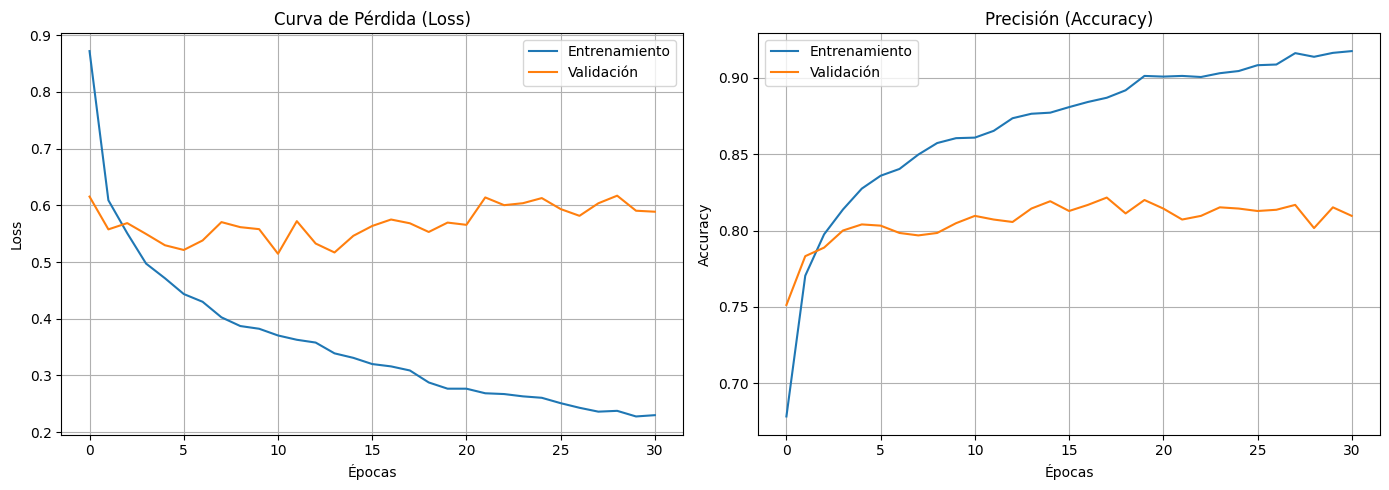

In [6]:
# Curvas de aprendizaje
from src.visualization import plot_learning_curve_keras
plot_learning_curve_keras(history)


196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Reporte ANN:

              precision    recall  f1-score   support

        fist       0.87      0.94      0.90      1250
        open       0.83      0.83      0.83      1250
       pinch       0.89      0.84      0.86      1250
      waveIn       0.90      0.87      0.89      1250
     waveOut       0.93      0.94      0.93      1250

    accuracy                           0.88      6250
   macro avg       0.88      0.88      0.88      6250
weighted avg       0.88      0.88      0.88      6250



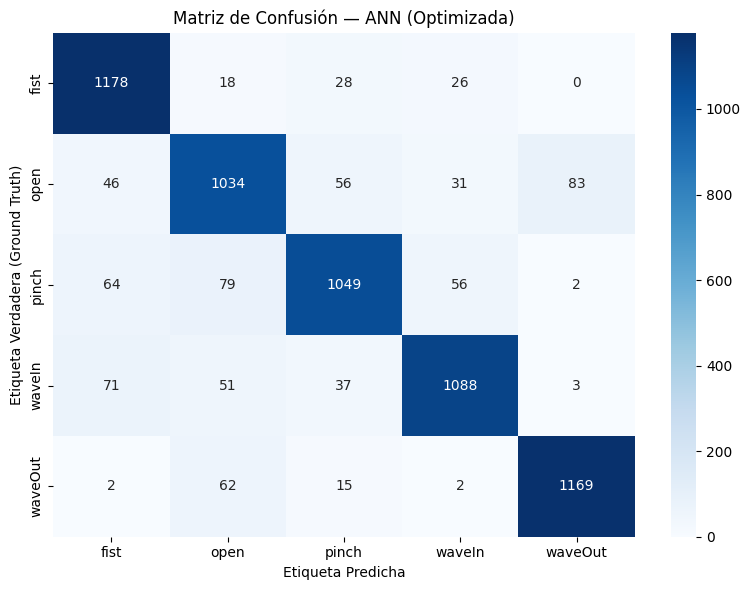

In [7]:
y_pred_enc = np.argmax(model.predict(X_test_s), axis=1)
y_pred     = encoder.inverse_transform(y_pred_enc)

print('Reporte ANN:\n')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = get_confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, class_names, title='Matriz de Confusión — ANN (Optimizada)')


In [8]:
models_dir = Config.PROCESSED_DIR / 'models'
os.makedirs(models_dir, exist_ok=True)
model.save(models_dir / 'best_ann_model.h5')
joblib.dump(scaler,  models_dir / 'ann_scaler.pkl')
joblib.dump(encoder, models_dir / 'ann_encoder.pkl')
print(f'Modelos guardados en {models_dir}')


Modelos guardados en /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann/data/processed/models
